# Phase 3 - Machine Learning
## Détection de fraude par classification
Modèles : Logistic Regression, Random Forest, XGBoost
Métriques : AUC-ROC, Precision, Recall, F1-Score

In [29]:
import subprocess
subprocess.run(["pip", "install", "xgboost", "scikit-learn", "imbalanced-learn"], 
               capture_output=True)
print("✓ Librairies installées")


✓ Librairies installées


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, 
                             precision_recall_curve, average_precision_score)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

print("✓ Imports terminés")

✓ Imports terminés


In [31]:
df = pd.read_csv("../creditcard.csv")
# Séparation features / target
X = df.drop('Class', axis=1)
y = df['Class']

# Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Normalisation du montant et du temps
scaler = StandardScaler()
X_train[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test[['Amount', 'Time']] = scaler.transform(X_test[['Amount', 'Time']])

print(f"✓ Train : {X_train.shape[0]:,} lignes")
print(f"✓ Test  : {X_test.shape[0]:,} lignes")
print(f"✓ Fraudes dans le test : {y_test.sum()} cas")

✓ Train : 227,845 lignes
✓ Test  : 56,962 lignes
✓ Fraudes dans le test : 98 cas


In [32]:
# MODÈLE 1 : Logistic Regression
print("Entraînement Logistic Regression...")
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"✓ AUC-ROC : {auc_lr:.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Fraude']))

Entraînement Logistic Regression...
✓ AUC-ROC : 0.9722

Rapport de classification :
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56864
      Fraude       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [33]:
# MODÈLE 2 : Random Forest
print("Entraînement Random Forest (patience...)")
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', 
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"✓ AUC-ROC : {auc_rf:.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Fraude']))

Entraînement Random Forest (patience...)
✓ AUC-ROC : 0.9529

Rapport de classification :
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [34]:
# MODÈLE 3 : XGBoost
print("Entraînement XGBoost...")
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(scale_pos_weight=scale_pos, random_state=42, 
                     eval_metric='auc', verbosity=0)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"✓ AUC-ROC : {auc_xgb:.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'Fraude']))

Entraînement XGBoost...
✓ AUC-ROC : 0.9726

Rapport de classification :
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [35]:
# Tableau comparatif
resultats = pd.DataFrame({
    'Modèle': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [round(auc_lr, 4), round(auc_rf, 4), round(auc_xgb, 4)],
    'Recall Fraude': [
        round(classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall'], 4),
        round(classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall'], 4),
        round(classification_report(y_test, y_pred_xgb, output_dict=True)['1']['recall'], 4)
    ],
    'Precision Fraude': [
        round(classification_report(y_test, y_pred_lr, output_dict=True)['1']['precision'], 4),
        round(classification_report(y_test, y_pred_rf, output_dict=True)['1']['precision'], 4),
        round(classification_report(y_test, y_pred_xgb, output_dict=True)['1']['precision'], 4)
    ]
})
print("=== COMPARATIF DES MODÈLES ===")
print(resultats.to_string(index=False))

=== COMPARATIF DES MODÈLES ===
             Modèle  AUC-ROC  Recall Fraude  Precision Fraude
Logistic Regression   0.9722         0.9184            0.0610
      Random Forest   0.9529         0.7449            0.9605
            XGBoost   0.9726         0.8265            0.8710


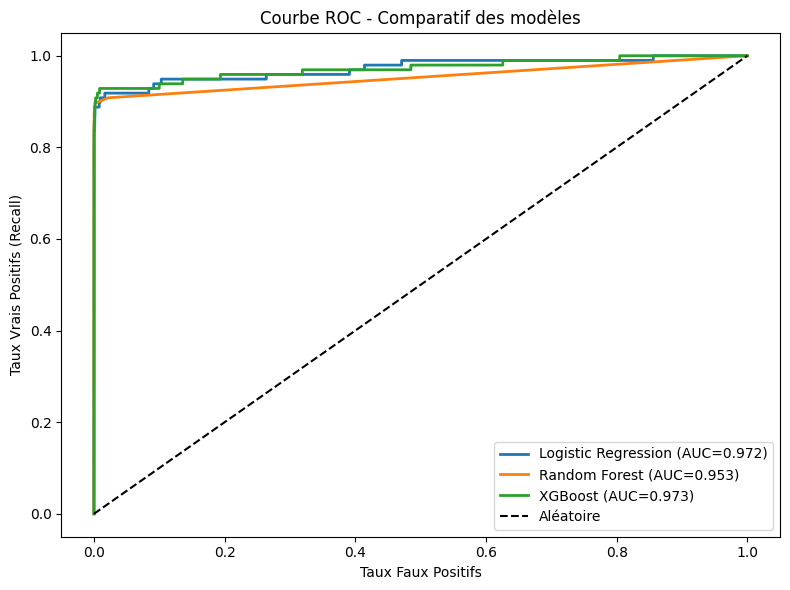

In [36]:
import os
os.makedirs("../reports", exist_ok=True)

plt.figure(figsize=(8, 6))
for y_prob, label, color in [
    (y_prob_lr, f'Logistic Regression (AUC={auc_lr:.3f})', '#3498db'),
    (y_prob_rf, f'Random Forest (AUC={auc_rf:.3f})', '#2ecc71'),
    (y_prob_xgb, f'XGBoost (AUC={auc_xgb:.3f})', '#e74c3c')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=label, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
plt.xlabel('Taux Faux Positifs')
plt.ylabel('Taux Vrais Positifs (Recall)')
plt.title('Courbe ROC - Comparatif des modèles')
plt.legend()
plt.tight_layout()
plt.savefig("../reports/roc_curve.png")
plt.show()

Calcul SHAP (patience ~1 minute)...


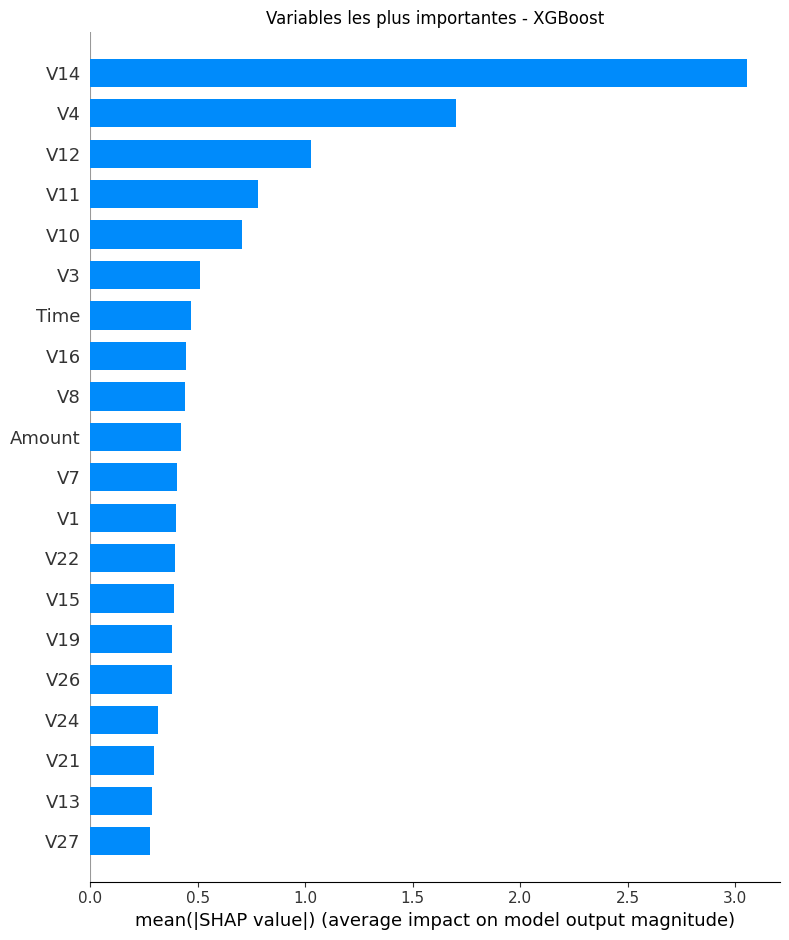

✓ Graphique SHAP sauvegardé


In [37]:
import subprocess
subprocess.run(["pip", "install", "shap"], capture_output=True)
import shap

print("Calcul SHAP (patience ~1 minute)...")
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test[:500])

plt.figure()
shap.summary_plot(shap_values, X_test[:500], plot_type="bar", show=False)
plt.title("Variables les plus importantes - XGBoost")
plt.tight_layout()
plt.savefig("../reports/shap_importance.png")
plt.show()
print("✓ Graphique SHAP sauvegardé")

In [38]:
print("=" * 55)
print("   RÉSUMÉ PHASE 3 - MACHINE LEARNING")
print("=" * 55)
print(f"{'Modèle':<25} {'AUC-ROC':<12} {'Recall':<10} {'Precision'}")
print("-" * 55)
print(f"{'Logistic Regression':<25} {auc_lr:<12.4f} {classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall']:<10.4f} {classification_report(y_test, y_pred_lr, output_dict=True)['1']['precision']:.4f}")
print(f"{'Random Forest':<25} {auc_rf:<12.4f} {classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall']:<10.4f} {classification_report(y_test, y_pred_rf, output_dict=True)['1']['precision']:.4f}")
print(f"{'XGBoost ✓ MEILLEUR':<25} {auc_xgb:<12.4f} {classification_report(y_test, y_pred_xgb, output_dict=True)['1']['recall']:<10.4f} {classification_report(y_test, y_pred_xgb, output_dict=True)['1']['precision']:.4f}")
print("=" * 55)
print("✓ Phase 3 - Machine Learning terminée !")
print("→ Prochaine étape : Dashboard Power BI")

   RÉSUMÉ PHASE 3 - MACHINE LEARNING
Modèle                    AUC-ROC      Recall     Precision
-------------------------------------------------------
Logistic Regression       0.9722       0.9184     0.0610
Random Forest             0.9529       0.7449     0.9605
XGBoost ✓ MEILLEUR        0.9726       0.8265     0.8710
✓ Phase 3 - Machine Learning terminée !
→ Prochaine étape : Dashboard Power BI


In [39]:
import os
import pandas as pd

# Recharger les données
df = pd.read_csv("../creditcard.csv")

os.makedirs("../dashboard", exist_ok=True)

# Créer le fichier Power BI
df_powerbi = df[['Time', 'Amount', 'Class']].copy()
df_powerbi['type_reel'] = df_powerbi['Class'].map({0: 'Normal', 1: 'Fraude'})
df_powerbi['heure'] = (df_powerbi['Time'] % 86400 / 3600).astype(int)
df_powerbi['periode'] = df_powerbi['heure'].apply(
    lambda h: '00h-06h' if h < 6 else '06h-12h' if h < 12 else '12h-18h' if h < 18 else '18h-24h')
df_powerbi['tranche_montant'] = df_powerbi['Amount'].apply(
    lambda x: '< 10€' if x < 10 else '10-50€' if x < 50 else '50-100€' if x < 100 else '100-500€' if x < 500 else '> 500€')

df_powerbi.to_csv("../dashboard/data_powerbi.csv")
print(f"✓ Fichier exporté : data_powerbi.csv")
print(f"✓ {len(df_powerbi):,} lignes prêtes pour Power BI")

✓ Fichier exporté : data_powerbi.csv
✓ 284,807 lignes prêtes pour Power BI


## Tableau comparatif des modèles

In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Modèle': ['Régression Logistique', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [auc_lr, auc_rf, auc_xgb],
    'Precision (Fraude)': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall (Fraude)': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1-score (Fraude)': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

comparison = comparison.round(4)
print(comparison.to_string(index=False))
comparison

               Modèle  AUC-ROC  Precision (Fraude)  Recall (Fraude)  F1-score (Fraude)
Régression Logistique   0.9722              0.0610           0.9184             0.1144
        Random Forest   0.9529              0.9605           0.7449             0.8391
              XGBoost   0.9726              0.8710           0.8265             0.8482


,Modèle,AUC-ROC,Precision (Fraude),Recall (Fraude),F1-score (Fraude)
0,Régression Logistique,0.9722,0.0610,0.9184,0.1144
1,Random Forest,0.9529,0.9605,0.7449,0.8391
2,XGBoost,0.9726,0.8710,0.8265,0.8482


## Courbes ROC comparées


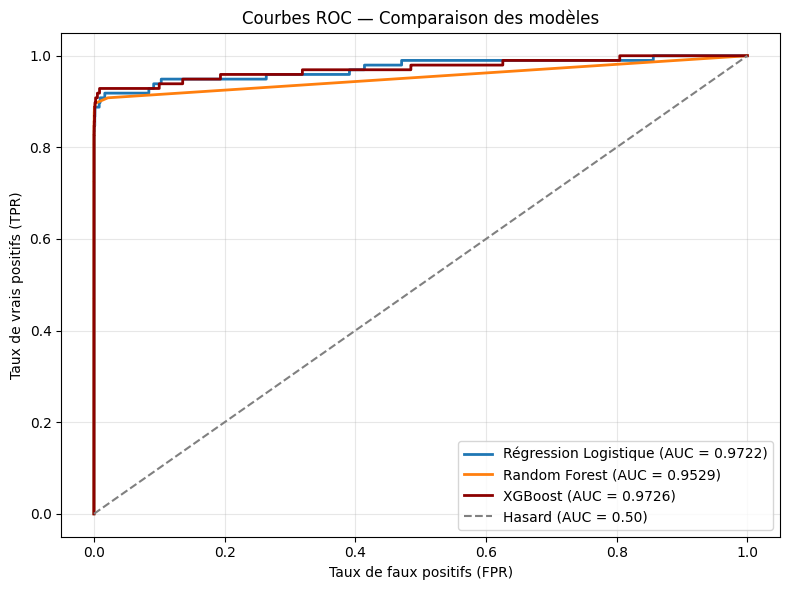

In [41]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

# Calcul des courbes ROC pour chaque modèle
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.plot(fpr_lr, tpr_lr, label=f'Régression Logistique (AUC = {auc_lr:.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', linewidth=2, color='darkred')

# Ligne de référence (modèle aléatoire)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Hasard (AUC = 0.50)')

plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbes ROC — Comparaison des modèles')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/roc_curves_comparison.png", dpi=150)
plt.show()